In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import plotly.graph_objects as go
import plotly.io as pio


list of TFs enriched in episodic

In [ ]:

all_path = "/work/nvme/bhdw/asachan/data_files/firefate/bcell/celloracle_PS_files/B_cell_all_scores.csv"

all = pd.read_csv(all_path)

all.head() 

,goi,pb_score,gc_score,pb_neg_ps,gc_neg_ps,pb_pos_ps,gc_pos_ps,n_pb_cells,n_gcbc_cells,PB_score_mean_ratio,GC_score_mean_ratio,log_ratio,log_ratio_compact,pb_total,gc_total,overall_total
0,PAX5,159.416755,69.149580,-4.812049,-64.085966,154.604705,5.063614,2789,6342,0.011520,0.000012,6.829366,6.829366,159.416755,69.149580,228.566335
1,BACH2,143.935119,60.729770,-4.653133,-36.302222,139.281987,24.427548,2789,6342,0.010732,0.000106,4.616616,4.616616,143.935119,60.729770,204.664890
2,BCL11A,142.167805,51.069441,-4.818479,-48.688947,137.349326,2.380494,2789,6342,0.010220,0.000008,7.189664,7.189664,142.167805,51.069441,193.237246
3,ID2,150.426201,28.730076,-3.702349,-11.993790,146.723852,16.736285,2789,6342,0.014209,0.000220,4.167882,4.167882,150.426201,28.730076,179.156277
4,EBF1,127.446311,50.192202,-6.376537,-46.059811,121.069774,4.132391,2789,6342,0.006808,0.000014,6.176301,6.176301,127.446311,50.192202,177.638513


In [3]:
TFs_dynamic = ["CREB3L2", "IRF2", "IRF7", "MEF2C", "IKZF3", "CDC5L", "POU2F1", "MAX", 
"MEF2A", "IRF1", "USF2", "TFEC", "TEAD2", "IRF8"]

TFs_static = [
    "ARID5B", "PAX5", "TFEC", "PBX3", "BATF", "BACH2", "TCF12", "CREB3L2",
    "IRF4", "XBP1", "AFF1", "HIVEP2", "PRDM1", "RUNX2", "HERPUD1"
]

TFs_dynamic_scores = all[all["goi"].isin(TFs_dynamic)]
print(TFs_dynamic_scores.shape)
TFs_static_scores = all[all["goi"].isin(TFs_static)]
print(TFs_static_scores.shape)


(9, 16)
(15, 16)


In [4]:
# Combine both TF lists
exclude_tfs = set(TFs_static_scores['goi']) | set(TFs_dynamic_scores['goi'])
print(len(exclude_tfs))
# Filter dataframe
subset_df = all[~all["goi"].isin(exclude_tfs)]

static_dynamic_df = all[all["goi"].isin(exclude_tfs)]

# Optional: check result
print(subset_df.shape)
print(static_dynamic_df.shape)

22
(216, 16)
(22, 16)


In [5]:
allexceptdynamic_df = all[~all["goi"].isin(TFs_dynamic_scores['goi'])]
print(allexceptdynamic_df.shape)

u_stat, p_value = stats.mannwhitneyu(
    TFs_dynamic_scores["overall_total"],
    allexceptdynamic_df["overall_total"],
    #alternative="two-sided"
    alternative="greater"
)

print("Mann–Whitney U p-value for dynamic:", p_value)

(229, 16)
Mann–Whitney U p-value for dynamic: 0.004781178766157048


In [6]:
u_stat, p_value = stats.mannwhitneyu(
    TFs_dynamic_scores["overall_total"],
    subset_df["overall_total"],
    #alternative="two-sided"
    alternative="greater"
)

print("Mann–Whitney U p-value for dynamic:", p_value)

u_stat, p_value = stats.mannwhitneyu(
    TFs_static_scores["overall_total"],
    subset_df["overall_total"],
    #alternative="two-sided"
    alternative="greater"
)

print("Mann–Whitney U p-value for static:", p_value)

u_stat, p_value = stats.mannwhitneyu(
    static_dynamic_df["overall_total"],
    subset_df["overall_total"],
    #alternative="two-sided"
    alternative="greater"
)

print("Mann–Whitney U p-value for static+dynamic:", p_value)

Mann–Whitney U p-value for dynamic: 0.0020406299604128486
Mann–Whitney U p-value for static: 7.583450580656125e-09
Mann–Whitney U p-value for static+dynamic: 4.9538878307570665e-09


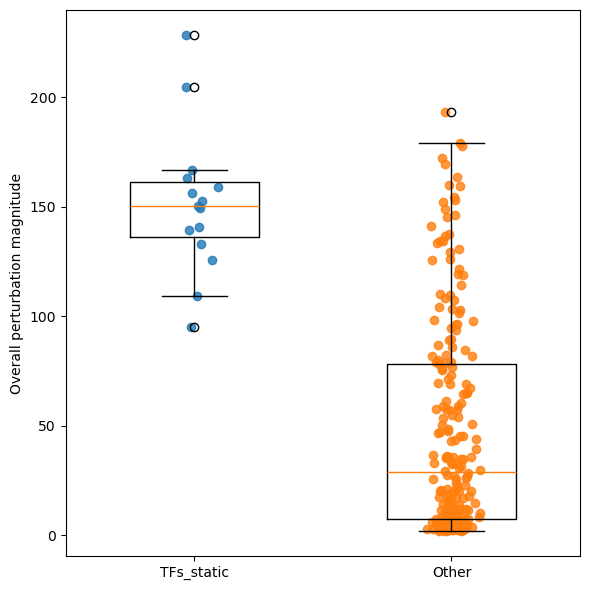

In [8]:

plt.figure(figsize=(6,6))

positions = [1, 2]
data = [
    TFs_static_scores["overall_total"],
    subset_df["overall_total"]
]
labels = ["TFs_static", "Other"]

# boxplot
plt.boxplot(data, positions=positions, widths=0.5)

# overlay individual TF points
for i, group in enumerate([TFs_static_scores, subset_df]):
    y = group["overall_total"].values
    x = np.random.normal(positions[i], 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.8)

plt.xticks(positions, labels)
plt.ylabel("Overall perturbation magnitude")

plt.tight_layout()
plt.show()

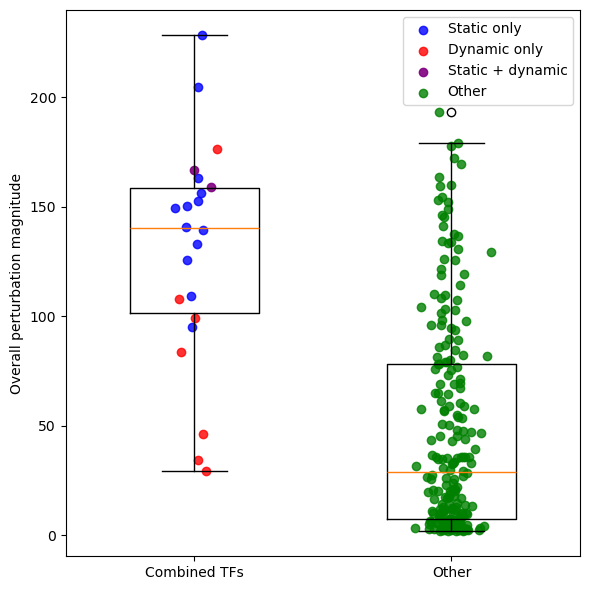

In [9]:
output_path = "/ocean/projects/cis240075p/heidarir/CellOracle_Tonsil_Bcells/Notebooks/06_PerturbationScore/Bcell_static_dynmic_other"  

plt.figure(figsize=(6, 6))

positions = [1, 2]

# Identify TFs shared between static and dynamic
common_idx = TFs_static_scores.index.intersection(TFs_dynamic_scores.index)

# Split into non-overlapping groups
static_only_vals = TFs_static_scores.drop(common_idx)["overall_total"].values
dynamic_only_vals = TFs_dynamic_scores.drop(common_idx)["overall_total"].values
shared_vals = TFs_dynamic_scores.loc[common_idx, "overall_total"].values

# Combined TFs for boxplot, without duplicating shared TFs
combined = np.concatenate([
    static_only_vals,
    dynamic_only_vals,
    shared_vals
])

data = [
    combined,
    subset_df["overall_total"].values
]

# Boxplot
plt.boxplot(data, positions=positions, widths=0.5)

# Static-only TFs
x_static = np.random.normal(positions[0], 0.04, size=len(static_only_vals))
plt.scatter(
    x_static,
    static_only_vals,
    alpha=0.8,
    color="blue",
    label="Static only"
)

# Dynamic-only TFs
x_dynamic = np.random.normal(positions[0], 0.04, size=len(dynamic_only_vals))
plt.scatter(
    x_dynamic,
    dynamic_only_vals,
    alpha=0.8,
    color="red",
    label="Dynamic only"
)

# Shared static + dynamic TFs
x_shared = np.random.normal(positions[0], 0.04, size=len(shared_vals))
plt.scatter(
    x_shared,
    shared_vals,
    alpha=0.9,
    color="purple",
    label="Static + dynamic"
)

# Other TFs
other_vals = subset_df["overall_total"].values
x_other = np.random.normal(positions[1], 0.04, size=len(other_vals))
plt.scatter(
    x_other,
    other_vals,
    alpha=0.8,
    color="green",
    label="Other"
)

plt.xticks(positions, ["Combined TFs", "Other"])
plt.ylabel("Overall perturbation magnitude")
plt.legend()

plt.tight_layout()

# Save files
plt.savefig(f"{output_path}.svg", format="svg", bbox_inches="tight")
plt.savefig(f"{output_path}.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Did not use the below code

In [ ]:

plt.figure(figsize=(6,6))

positions = [1, 2, 3]  # FIX: match 3 groups
data = [
    TFs_static_scores["overall_total"],
    TFs_dynamic_scores["overall_total"],
    subset_df["overall_total"]
]
labels = ["TFs_static", "TFs_dynamic", "Other"]

# boxplot
plt.boxplot(data, positions=positions, widths=0.5)

# overlay individual TF points
for i, group in enumerate([TFs_static_scores, TFs_dynamic_scores, subset_df]):
    y = group["overall_total"].values
    x = np.random.normal(positions[i], 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.8)

plt.xticks(positions, labels)
plt.ylabel("Overall perturbation magnitude")

plt.tight_layout()
plt.show()

In [16]:
!pip install nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [nbformat]5/6 [nbformat]a]specifications]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
fig.write_image("/ocean/projects/cis240075p/heidarir/CellOracle_Tonsil_Bcells/out_data/PS_Bcell/Boxplots_Final/Bcell_static.svg")

In [33]:
!pip install --upgrade kaleido


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import plotly.graph_objects as go
import plotly.io as pio

fig = go.Figure()

# TFs_static box
fig.add_trace(go.Box(
    y=TFs_static_scores["overall_total"],
    name="TFs_static",
    boxpoints="all",
    jitter=0.35,
    pointpos=0,
    fillcolor="rgba(0,0,0,0)",
    line=dict(color="black"),
    marker=dict(color="green", opacity=0.8, size=6),
    showlegend=False
))

# TFs_dynamic box
fig.add_trace(go.Box(
    y=TFs_dynamic_scores["overall_total"],
    name="TFs_dynamic",
    boxpoints="all",
    jitter=0.35,
    pointpos=0,
    fillcolor="rgba(0,0,0,0)",
    line=dict(color="black"),
    marker=dict(color="red", opacity=0.8, size=6),
    showlegend=False
))

# Other box
fig.add_trace(go.Box(
    y=subset_df["overall_total"],
    name="Other",
    boxpoints="all",
    jitter=0.35,
    pointpos=0,
    fillcolor="rgba(0,0,0,0)",
    line=dict(color="black"),
    marker=dict(color="blue", opacity=0.8, size=6),
    showlegend=False
))

# Legend markers
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(color="green", size=8),
    name="TFs_static"
))

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(color="red", size=8),
    name="TFs_dynamic"
))

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(color="blue", size=8),
    name="Other"
))

# --- significance brackets ---
max_y = max(
    TFs_static_scores["overall_total"].max(),
    TFs_dynamic_scores["overall_total"].max(),
    subset_df["overall_total"].max()
)

y1 = max_y * 1.08
y2 = max_y * 1.22
tick = max_y * 0.02
text_offset = max_y * 0.015

# TFs_static vs Other
fig.add_shape(
    type="line",
    x0=0, x1=2,
    y0=y1, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_shape(
    type="line",
    x0=0, x1=0,
    y0=y1 - tick, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_shape(
    type="line",
    x0=2, x1=2,
    y0=y1 - tick, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_annotation(
    x=1,
    y=y1 + text_offset,
    text="*",
    showarrow=False,
    font=dict(size=22)
)

# TFs_dynamic vs Other
fig.add_shape(
    type="line",
    x0=1, x1=2,
    y0=y2, y1=y2,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_shape(
    type="line",
    x0=1, x1=1,
    y0=y2 - tick, y1=y2,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_shape(
    type="line",
    x0=2, x1=2,
    y0=y2 - tick, y1=y2,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)
fig.add_annotation(
    x=1.5,
    y=y2 + text_offset,
    text="*",
    showarrow=False,
    font=dict(size=22)
)

fig.update_layout(
    yaxis_title="Overall perturbation score",
    width=600,
    height=600,
    template="simple_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1
    )
)

pio.renderers.default = "browser"
fig.show()

In [ ]:
fig.write_image("/ocean/projects/cis240075p/heidarir/CellOracle_Tonsil_Bcells/out_data/PS_Bcell/Boxplots_Final/Bcell_static_dynamic.svg")

## Plotting Static+Dynamic vs. Others

In [18]:
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np
from scipy.stats import mannwhitneyu

fig = go.Figure()

# values
static_vals = TFs_static_scores["overall_total"].dropna()
dynamic_vals = TFs_dynamic_scores["overall_total"].dropna()
other_vals = subset_df["overall_total"].dropna()

combined_vals = np.concatenate([static_vals, dynamic_vals])

# Mann-Whitney U test: combined TFs vs Other
stat, pval = mannwhitneyu(combined_vals, other_vals, alternative="two-sided")

# Combined TFs boxplot
fig.add_trace(go.Box(
    y=combined_vals,
    x=["TFs_static_dynamic"] * len(combined_vals),
    name="TFs_static_dynamic",
    boxpoints=False,
    fillcolor="rgba(0,0,0,0)",
    line=dict(color="black"),
    showlegend=False
))

# Static points on combined box
fig.add_trace(go.Scatter(
    x=["TFs_static_dynamic"] * len(static_vals),
    y=static_vals,
    mode="markers",
    marker=dict(color="green", opacity=0.8, size=6),
    name="TFs_static"
))

# Dynamic points on combined box
fig.add_trace(go.Scatter(
    x=["TFs_static_dynamic"] * len(dynamic_vals),
    y=dynamic_vals,
    mode="markers",
    marker=dict(color="red", opacity=0.8, size=6),
    name="TFs_dynamic"
))

# Other boxplot
fig.add_trace(go.Box(
    y=other_vals,
    x=["Other"] * len(other_vals),
    name="Other",
    boxpoints="all",
    jitter=0.35,
    pointpos=0,
    fillcolor="rgba(0,0,0,0)",
    line=dict(color="black"),
    marker=dict(color="blue", opacity=0.8, size=6),
    showlegend=False
))

# Legend marker for Other
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(color="blue", size=8),
    name="Other"
))

# --- significance bracket ---
max_y = max(np.max(combined_vals), np.max(other_vals))

y1 = max_y * 1.08
tick = max_y * 0.02
text_offset = max_y * 0.015

fig.add_shape(
    type="line",
    x0=0, x1=1,
    y0=y1, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)

fig.add_shape(
    type="line",
    x0=0, x1=0,
    y0=y1 - tick, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)

fig.add_shape(
    type="line",
    x0=1, x1=1,
    y0=y1 - tick, y1=y1,
    xref="x", yref="y",
    line=dict(color="black", width=2)
)

fig.add_annotation(
    x=0.5,
    y=y1 + text_offset,
    text=f"p = {pval:.2e}",
    showarrow=False,
    font=dict(size=16)
)

fig.update_layout(
    yaxis_title="Overall perturbation score",
    width=600,
    height=600,
    template="simple_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        categoryorder="array",
        categoryarray=["TFs_static_dynamic", "Other"],
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1
    )
)

pio.renderers.default = "browser"
fig.show()